In [8]:
from DeepImageSearch import Load_Data,Search_Setup
import sys
import os
from PIL import Image

In [9]:
# تهيئه محرك البحث خد بالك يا ديشا الخليه دى بتترن مره واحده بس!!
# ولو رنيتها غلط دوس على زرار ESC
def create_search_engine(folder_path):
    """
    You Run this Function Once time!!!
        
    Parameters:
    - folder_path (str): The path to the folder.

    Returns:
    - st: A Search Enginge SetUp
    - image_list: List of images that will be added to search engine metadata
    - metadata: 
    """
    # Load images from a folder
    image_list = Load_Data().from_folder([folder_path])

    # Set up the search engine
    st = Search_Setup(image_list=image_list, model_name='vgg19', 
                      pretrained=True, image_count=len(image_list))

    # Index the images
    st.run_index()

    # Get metadata
    metadata = st.get_image_metadata_file()

    # Return search_setup
    return st, image_list, metadata


def is_valid_folder(folder_path):
    """
    Check if the given folder path is valid.

    Parameters:
    - folder_path (str): The path to the folder.

    Returns:
    - bool: True if the folder is valid, False otherwise.
    """
    return os.path.isdir(folder_path)

def is_valid_image(file_path):
    """
    Check if the given file is a valid image.

    Parameters:
    - file_path (str): The path to the file.

    Returns:
    - bool: True if the file is a valid image, False otherwise.
    """
    try:
        with Image.open(file_path) as img:
            # The file is a valid image if the open() method succeeds.
            return True
    except (IOError, OSError):
        # The open() method may raise IOError or OSError for invalid images.
        return False

def filter_valid_images(image_paths):
    """
    Filter out valid images from a list of image file paths.

    Parameters:
    - image_paths (list): List of file paths.

    Returns:
    - valid_images (list): List of valid image file paths.
    - invalid_images (list): List of invalid image file paths.
    """
    valid_images = []
    invalid_images = []

    for file_path in image_paths:
        if is_valid_image(file_path):
            valid_images.append(file_path)
        else:
            invalid_images.append(file_path)

    return valid_images, invalid_images


# return 3 similar images from database after searching

# Get similar images paths
def get_similar_images_path(image_path, num_images=3):
    """
    Get similar image path, After Searchin in metadata.
    
    Parameters:
    - image_paths (list): List of file paths.
    - num_images: Number of images that you want to return after searching process.

    Returns:
    - similar_image_path (Dict): Dictionary of similar image path from data database,
                                 Key=index_of_image, value=image_path. 
    """
    similar_image_path = st.get_similar_images(image_path=image_path, number_of_images=num_images)
    return similar_image_path

# Plot similar images
def plot_similar_images(image_path, num_images=3):
    """
    Plots a given image and its most similar images according to the indexed image features.
    
    Parameters:
    - image_paths (list): List of file paths.
    - num_images: Number of images that you want to plot after searching process.
    """
    similar_image_path = st.plot_similar_images(image_path=image_path,number_of_images=num_images)
    print(similar_image_path)

def updating_images_and_metadata(list_images) -> (list):
    """
    Updating images in Search Enginge Database, When New Images been added to Database.
    
    Parameters:
    - list_images (List): list of new images that been added to Database,
                          To adding it in search enginge metadata
    """
    new_img_list = []

    # checking for new images to been added to metadata if it not exist
    for img in list_images:
        if img not in list_images:
            new_img_list.append(img)
        

    st.add_images_to_index(new_image_paths=new_img_list)
    metadata = st.get_image_metadata_file()
    return metadata

 Please Wait Model Is Loading or Downloading From Server!


 Model Loaded Successfully: vgg19
 Metadata and Features are already present, Do you want Extract Again? Enter yes or no
 Meta data already Present, Please Apply Search!
['image_data_features.pkl', 'image_features_vectors.idx']


0it [00:00, ?it/s]

 New images added to the index: 0
Valid Images:
['images/5b9ceb964c679100.jpg', 'images/wallet2.jpeg', 'images/photo_1_2023-12-29_18-17-00.jpg', 'images/photo_2_2024-01-15_04-15-46.jpg', 'images/phone.jpeg', 'images/photo_2023-12-30_20-49-56.jpg', 'images/Untitled2.jpeg', 'images/photo_3_2023-12-30_20-34-39.jpg', 'images/4d7520d287589423.jpg', 'images/photo_3_2024-01-15_04-15-46.jpg', 'images/62834e3701cf17e5.jpg', 'images/Untitled.jpeg', 'images/photo_6_2024-01-15_04-15-46.jpg', 'images/tab.jpeg', 'images/wallet.jpeg', 'images/cat.jpeg', 'images/10fd08d7-IMG20230418203821_jpg.rf.77089d3741da37fec0b72ea0f55fa366.jpg', 'images/6dbd48b4cf3f8220.jpg', 'images/photo_4_2024-01-15_04-15-46.jpg', 'images/a5835819-IMG20230418204622_jpg.rf.574ef9b3b57853da06e4a4a48996a70c.jpg', 'images/1b2c9407-IMG20230418205412_jpg.rf.7ff609e97e2520417302bc6884d43f33.jpg', 'images/photo_1_2024-01-15_04-15-46.jpg']

Invalid Images:
[]


{5: 'images/photo_2023-12-30_20-49-56.jpg', 8: 'images/4d7520d287589423.jpg', 12: 'images/photo_6_2024-01-15_04-15-46.jpg'}


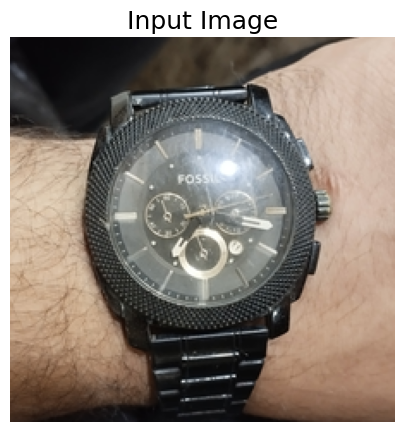

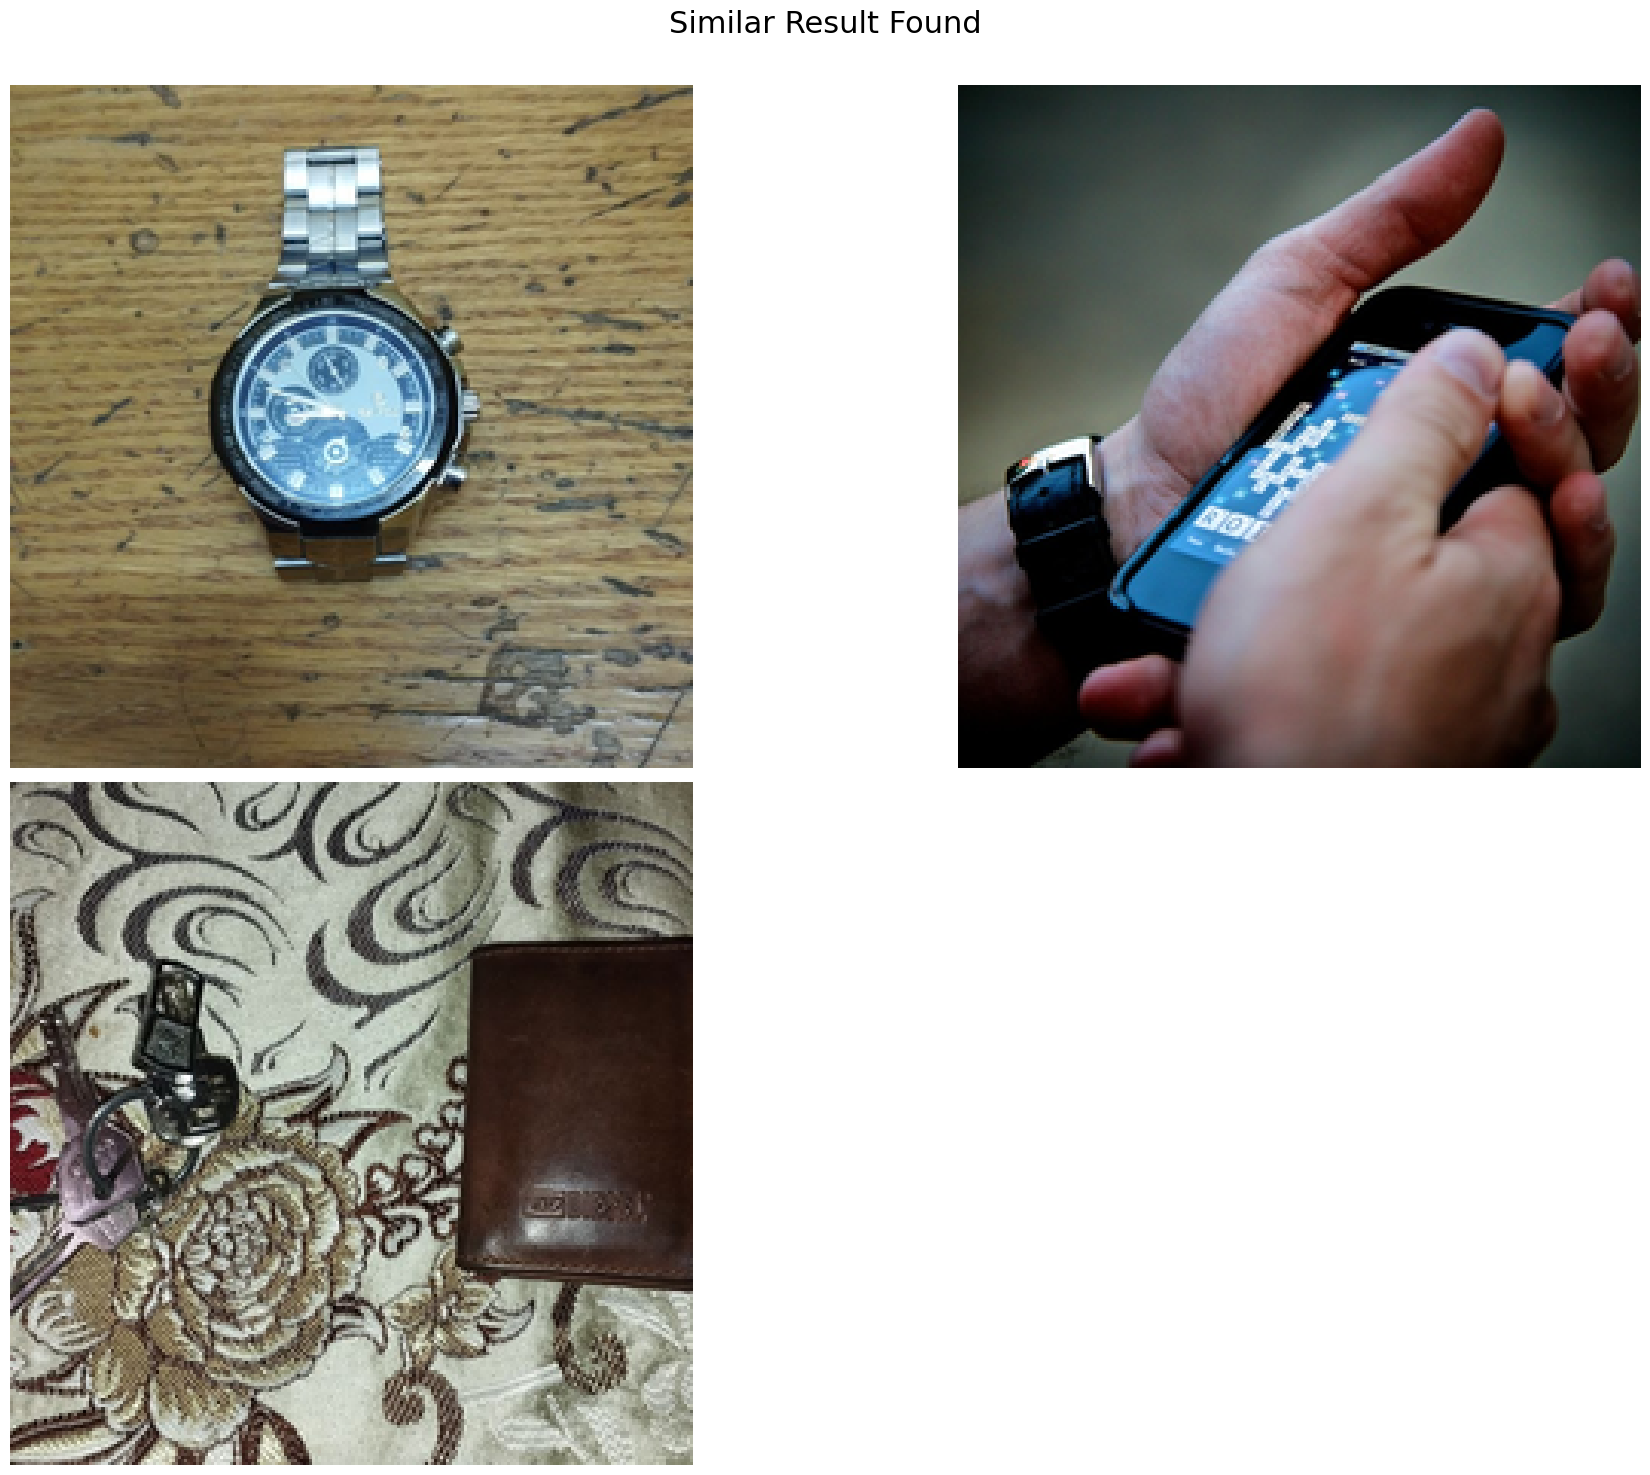

None


In [10]:
# Main Program
# Example usage:
folder_path = 'images'  # حط الطريق الكامل لفولدر الصور

if is_valid_folder(folder_path):
    # st refers to search_enging_setup
    st, image_list, metadata = create_search_engine(folder_path=folder_path)
else:
    print(f"{folder_path} is not a valid folder.")
    sys.exit

# checks if image to search  in metadata or not
check_new_img = ['/home/hossam/python_projects/last_projects/images.jpeg'] # تحط فى اللسته دى الصور الجديده اللى إترفعت على السيرفر كحجات ضايعه مش صوره ادور على حاجه تشبها
imgs_metadata_list = metadata.images_paths.tolist()

# ضيف الصور الجديده للداتا بيز عشان اضيفهم لعمليات البحث
metadata = updating_images_and_metadata(list_images=check_new_img)

# رجعلى بعد فلترة الصور, ايه الصور السليمه والصور البايظه
valid_images, invalid_images = filter_valid_images(image_list)

print("Valid Images:")
print(valid_images)

print("\nInvalid Images:")
print(invalid_images)

# الصوره اللى عايز تعمل بحث عن حاجه شبها
get_path_similar_images = '/home/hossam/python_projects/last_projects/deep_image_search/1705693435308.jpg'

# رجعلى طريق 3 صور قريبين للصوره اللى بدور عليها واظهرهم
if is_valid_image(get_path_similar_images):
    similar_image_path = get_similar_images_path(image_path=get_path_similar_images)
    print(similar_image_path)

    plot_similar_image = plot_similar_images(image_path=get_path_similar_images)
else:
    print('Invalid Image')